In [1]:
import random
from datetime import datetime, timedelta, time


In [2]:
from SIM.Simulator import dwelling
from SIM.Simulator_Config.config_list_train import (pv_config,
                                                        ev_config,
                                                        thermal_config,
                                                        weather_file,
                                                        demand_config,
                                                        battery_config)

from Controller.HEMSControlRule import HEMSController
from SIM.Tariff.TariffGenerator import RandomTariffGenerator

NumPy version: 2.4.6
PyTorch built with NumPy: PyTorch built with:
  - GCC 13.3
  - C++ Version: 202002
  - Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.11.2 (Git Hash 03c022d3ffdcee958cfacbe720048e725fdf644c)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 13.0
  - NVCC architecture flags: -gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,code=sm_86;-gencode;arch=compute_90,code=sm_90;-gencode;arch=compute_100,code=sm_100;-gencode;arch=compute_120,code=sm_120
  - CuDNN 92.0  (built against CUDA 13.2)
  - Magma 2.6.1
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, COMMIT_SHA=7661cd9c6b841b62b7f411aa52ec51f05457263b, CUDA_FLAGS= -DLIBCUDACXX_ENABLE_SIMPLIFIED_COMPLEX_OPERATIONS -Xfatbin -compress-all -DONNX_NAMESPACE=onnx_torch -genco

In [3]:
RES = 60
RESOLUTION = timedelta(minutes=RES)  # 1 min resolution info
DURATION = timedelta(days=10)
START_TIME = datetime(2018, 1, 1)

### Defining Dwelling simulator with all system configuration
Check the config file in SIM/Simulator_Config

In [4]:
SEED = 0
House = dwelling(name='Dwelling_1',
                 start_time=START_TIME,
                 resolution=RESOLUTION,
                 duration=DURATION,
                 demand_config=demand_config,
                 weather_file=None,
                 pv_config=pv_config,
                 battery_config=battery_config,
                 ev_config=None,
                 thermal_config=None,
                 seed=SEED)

Simulator: Start time: 2018-01-01 00:00:00: End time:2018-01-11 00:00:00


#### Defining Tariff handler to handle day to day tariff [here it 24 hrs ahead tariff ]

In [5]:
Tariff_gen = RandomTariffGenerator(low=0.1, high=0.4, resolution=timedelta(minutes=RES), seed=SEED)
House.tariff.tariff_model = Tariff_gen
House.tariff.feed_tariff_model = Tariff_gen
House.tariff.generate_tariff()  # First Generate
House.tariff.updated_tariff()  # Then Update
House.initialized_df()

Simulator: Setup up the demand profile for simulation
Simulator: No weather file detected: self.weather = None
Simulator: {'type': 'train', 'seed': 1, 'capacity W': 10000, 'efficiency': 1, 'area per W': 1, 'tilt': 20, 'azimuth': 0, 'max_irradiance': 1000}
Simulator: PV conf detected setting up PV generation for training setup
Simulator: NO EVs found: Ignoring EV setup
Simulator: ==== Initializing ESS ====
Simulator: No thermal Load detected: Ignoring Thermal Load demand


#### Defining Controller recommended to pass the system info based on which control action and constraints can be defined

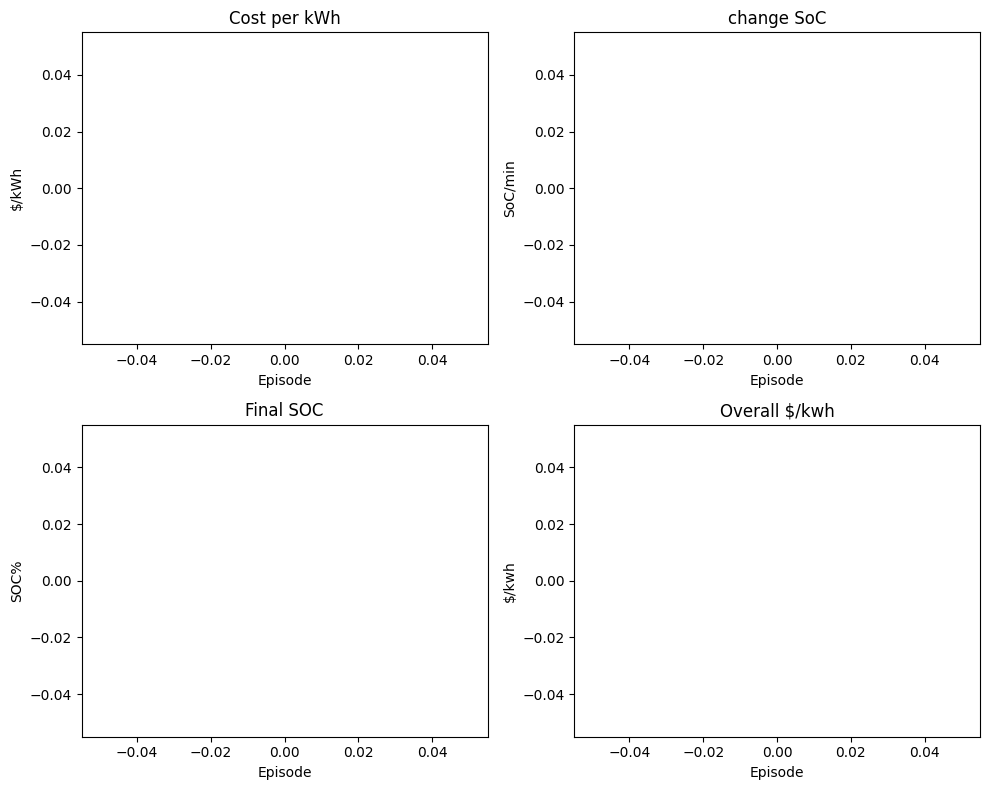

In [6]:
Controller = HEMSController(name='Dwelling_1', data_resolution=RESOLUTION, meter_tariff=House.tariff,
                            ev_update_period=timedelta(minutes=RES),
                            ess_update_period=timedelta(minutes=RES),
                            havc_update_period=timedelta(minutes=RES),
                            ev_config=ev_config,
                            ess_config=battery_config,
                            hvac_config=thermal_config)

In [7]:
current_time = START_TIME
end_time = START_TIME + DURATION
control_signal = {}

start = datetime.now()
day = 0
# Running a training loop
while current_time <= end_time-RESOLUTION:

    inverter, meter, ev, hvac, status = House.step(control_signal)
    # geting perfect future value

    Demand = House.simulation_df.loc[current_time+RESOLUTION, "Demand Electric Power (kW)"] # next period
    Generation = House.simulation_df.loc[current_time+RESOLUTION, "PV Electric Power (kW)"] # next period

    inverter.forecast_demand = Demand
    inverter.forecast_generation = Generation

    control_signal = Controller.update(ev_info=ev, inverter_info=inverter, hvac_info=hvac, meter_info=meter)

    if control_signal: # check control signal
        # print(control_signal)
        pass

    current_time += RESOLUTION
    if current_time.time() == time(12, 00):
        House.tariff.generate_tariff()
    elif current_time.time() == time(0, 0):
        House.tariff.updated_tariff()
        # update the SOC external for training
        next_soc = House.Battery.set_soc(random.uniform(0.05, 1)) # reset that will occur
        day +=1
    # only for RL approch wi
    if (day + 1) % 5 == 0 or day == 1000:
        percent = day / 1000 * 100
        if day == 1000:  # force 100% at the end
            percent = 100
        bar = '█' * int(percent / 5) + '-' * (20 - int(percent / 5))
        # print(f"\rSeed {SEED} |{bar}| {percent:.1f}% completed ::{day}:: {Controller.ess_controller.avg_reward}", end="")



end = datetime.now()
duration = (end - start).total_seconds()


In [9]:
print(f"Simulation took {duration:.4f} seconds")

print(f'Final House Cost: {Controller.hems_database.df["Instant Cost"].sum()}')

Controller.hems_database.df.to_csv('../Results/controller_train_EV_V2G.csv')
House.simulation_df.to_csv('../Results/simulation_train_EV_V2G.csv')

Simulation took 1.5878 seconds
Final House Cost: -13.085099999999999


In [10]:
Controller.hems_database.df

,Consumption (kW),Consumption (kWh),Generation (kW),Generation (kWh),Total Electric Power (kW),Total Electric Power (kWh),tariff,feed tariff,Instant Cost,Battery SOC (-),...,Battery Electric Power (kW),Battery Electric Energy (kWh),EV Parked,EV SOC (-),EV Set Point (kW),EV Electric Power (kW),EV Electric Energy (kWh),Temperature - Indoor (C),Heating Electric Power (kW),Heating Electric Energy (kWh)
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,5.118,5.118,6.370,6.370,-1.252,-1.252,0.29,0.28,-0.3506,1.0000,...,0.000,0.000,False,0.0,0,0.0,0.0,0.0,0.0,0.0
2018-01-01 01:00:00,9.505,9.505,2.698,2.698,6.807,6.807,0.18,0.22,1.2253,1.0000,...,0.000,0.000,False,0.0,0,0.0,0.0,0.0,0.0,0.0
2018-01-01 02:00:00,1.442,1.442,0.410,0.410,1.032,1.032,0.11,0.40,0.1135,1.0000,...,0.000,0.000,False,0.0,0,0.0,0.0,0.0,0.0,0.0
2018-01-01 03:00:00,9.486,9.486,0.165,0.165,9.321,9.321,0.10,0.39,0.9321,1.0000,...,0.000,0.000,False,0.0,0,0.0,0.0,0.0,0.0,0.0
2018-01-01 04:00:00,3.118,3.118,8.133,8.133,-7.515,-7.515,0.34,0.31,-2.3296,0.5000,...,-2.500,-2.500,False,0.0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-10 19:00:00,9.065,9.065,5.788,5.788,2.810,2.810,0.35,0.33,0.9835,0.9066,...,-0.467,-0.467,False,0.0,0,0.0,0.0,0.0,0.0,0.0
2018-01-10 20:00:00,2.261,2.261,1.972,1.972,0.756,0.756,0.30,0.35,0.2268,1.0000,...,0.467,0.467,False,0.0,0,0.0,0.0,0.0,0.0,0.0
2018-01-10 21:00:00,8.532,8.532,8.081,8.081,0.451,0.451,0.21,0.22,0.0947,1.0000,...,0.000,0.000,False,0.0,0,0.0,0.0,0.0,0.0,0.0
